# LearnedCache — YCSB evaluation visualizations

Renders the policy-evaluation results from `results/`:
`ycsb_eval_results.json` (5 classical policies), `ycsb_eval_protect.json` (ML-protect),
`ycsb_eval_lru.json` / `ycsb_eval_mglru.json` (Linux LRU / kernel MGLRU baselines) and
`ycsb_eval_ml{10,20,30,40}.json` (ML-rank oversampling sweep).
Per-workload matched models from `/mydata/models-jun-11` (see `ycsb_eval_meta.json`).

Setup: 240 s timed + 45 s warmup per config, 10 GiB cgroup, 8 CPUs, 1 iteration.
`ycsb_e` p99 uses SCAN p99 (READ p99 is 0 on the scan-only workload).
Figures are also written to `visualizations/figs/`.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

BASE = os.path.realpath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'visualizations' else '/mydata/cache_ext_lc'
RES, FIGS = os.path.join(BASE, 'results'), os.path.join(BASE, 'visualizations', 'figs')
os.makedirs(FIGS, exist_ok=True)

plt.rcParams.update({
    'font.family': 'monospace',
    'font.monospace': ['DejaVu Sans Mono'],
    'font.size': 12,
    'axes.titlesize': 16, 'axes.labelsize': 15,
    'axes.labelweight': 'normal', 'axes.titlepad': 10,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 10.5, 'legend.frameon': True, 'legend.framealpha': 0.95,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '-',
    'figure.dpi': 110, 'savefig.dpi': 170, 'savefig.bbox': 'tight',
    # opaque white background so labels stay readable in dark viewers
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.edgecolor': 'white',
    'savefig.transparent': False,
    'hatch.linewidth': 0.3,
})

COLORS = {
    'Linux LRU':           '#8D99AE',  # slate (Linux default, MGLRU off)
    'MGLRU (Linux)':       '#FF6B35',  # bright orange
    'MRU (cache_ext)':     '#9B5DE5',  # violet
    'FIFO (cache_ext)':    '#F15BB5',  # magenta
    'S3-FIFO (cache_ext)': '#8AC926',  # lime
    'LHD (cache_ext)':     '#1982C4',  # azure
    'LFU (cache_ext)':     '#FFCA3A',  # gold
    'ML-protect (ours)':   '#00BBF9',  # sky
    'ML-rank 10x (ours)':  '#B8F2E6',  # mint
    'ML-rank 20x (ours)':  '#64DFBB',
    'ML-rank 30x (ours)':  '#00C2A8',
    'ML-rank 40x (ours)':  '#008F7A',
}
MARKERS = {  # one shape per policy (image-style); ML-rank family shares a shape, varies by color
    'Linux LRU': 'o', 'MGLRU (Linux)': '^',
    'MRU (cache_ext)': 's', 'FIFO (cache_ext)': 'P', 'S3-FIFO (cache_ext)': 'X',
    'LHD (cache_ext)': 'D', 'LFU (cache_ext)': '*', 'ML-protect (ours)': 'h',
    'ML-rank 10x (ours)': 'o', 'ML-rank 20x (ours)': 'o',
    'ML-rank 30x (ours)': 'o', 'ML-rank 40x (ours)': 'o',
}
def disp(name):  # standardized display name for kernel baselines (dict keys unchanged)
    return {'Linux LRU': 'LRU (Linux)', 'MGLRU (Linux)': 'MGLRU (Linux)'}.get(name, name)

import matplotlib.colors as _mc
def text_on(color):  # black on light fills, white on dark -> readable in color AND greyscale
    r, g, b = _mc.to_rgba(color)[:3]
    return 'black' if (0.299*r + 0.587*g + 0.114*b) > 0.6 else 'white'

HATCHES = {  # distinct texture per policy so grouped bars separate in greyscale
    'Linux LRU': '', 'MGLRU (Linux)': '///', 'MRU (cache_ext)': '...',
    'FIFO (cache_ext)': 'xxx', 'S3-FIFO (cache_ext)': 'ooo', 'LHD (cache_ext)': '|||',
    'LFU (cache_ext)': '---', 'ML-protect (ours)': '+++', 'ML-rank 30x (ours)': '***',
    'ML-rank 10x (ours)': 'OO', 'ML-rank 20x (ours)': '//', 'ML-rank 40x (ours)': '..',
}

WORKLOADS = ['ycsb_a', 'ycsb_b', 'ycsb_c', 'ycsb_d', 'ycsb_e', 'ycsb_f']
WLABELS = ['YCSB\nA', 'YCSB\nB', 'YCSB\nC', 'YCSB\nD', 'YCSB\nE', 'YCSB\nF']
CLASSICAL = ['MRU (cache_ext)', 'FIFO (cache_ext)', 'S3-FIFO (cache_ext)',
             'LHD (cache_ext)', 'LFU (cache_ext)']

In [2]:
# --- load every results file into one tidy DataFrame ---
LOADER_LABEL = {
    'cache_ext_mru.out': 'MRU (cache_ext)', 'cache_ext_fifo.out': 'FIFO (cache_ext)',
    'cache_ext_s3fifo.out': 'S3-FIFO (cache_ext)', 'cache_ext_lhd.out': 'LHD (cache_ext)',
    'cache_ext_sampling.out': 'LFU (cache_ext)',
    'cache_ext_fifo_ml_protect.out': 'ML-protect (ours)',
}

def p99_ms(res, workload):
    lat = res.get('latency_p99') or 0.0
    if lat == 0.0:
        lat = res.get('scan_latency_p99') or 0.0
    return lat / 1e6

def rows_from(path, ml_label=None, baseline_label='MGLRU (Linux)'):
    if not os.path.exists(path):
        return []
    out = []
    for e in json.load(open(path)):
        cfg, res = e['config'], e['results']
        w = cfg.get('benchmark')
        if w not in WORKLOADS:
            continue
        if cfg.get('cgroup_name') == 'baseline_test':
            label = baseline_label
        else:
            loader = cfg.get('policy_loader')
            if loader == 'cache_ext_ml_sampling.out':
                label = ml_label  # ml_sampling rows live in per-factor ml<F> files
            else:
                label = LOADER_LABEL.get(loader)
        if not label:
            continue
        out.append({'workload': w, 'policy': label,
                    'tput': res.get('throughput_avg'),
                    'p99_ms': p99_ms(res, w),
                    'avg_ms': (res.get('latency_avg') or 0) / 1e6,
                    'read_p99_ms': (res.get('read_latency_p99') or 0) / 1e6,
                    'update_p99_ms': (res.get('update_latency_p99') or 0) / 1e6,
                    'scan_p99_ms': (res.get('scan_latency_p99') or 0) / 1e6})
    return out

df = pd.DataFrame(
    rows_from(os.path.join(RES, 'ycsb_eval_results.json'))
    + rows_from(os.path.join(RES, 'ycsb_eval_protect.json'))
    + rows_from(os.path.join(RES, 'ycsb_eval_lru.json'), baseline_label='Linux LRU')
    + rows_from(os.path.join(RES, 'ycsb_eval_mglru.json'))
    + rows_from(os.path.join(RES, 'ycsb_eval_ml10.json'), 'ML-rank 10x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml20.json'), 'ML-rank 20x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml30.json'), 'ML-rank 30x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml40.json'), 'ML-rank 40x (ours)'))

tput = df.pivot(index='workload', columns='policy', values='tput').reindex(WORKLOADS)
p99 = df.pivot(index='workload', columns='policy', values='p99_ms').reindex(WORKLOADS)
best_classical = tput[CLASSICAL].max(axis=1)
print(f'{len(df)} rows, {df.policy.nunique()} policies x {df.workload.nunique()} workloads')
tput.round(0)

72 rows, 12 policies x 6 workloads


policy,FIFO (cache_ext),LFU (cache_ext),LHD (cache_ext),Linux LRU,MGLRU (Linux),ML-protect (ours),ML-rank 10x (ours),ML-rank 20x (ours),ML-rank 30x (ours),ML-rank 40x (ours),MRU (cache_ext),S3-FIFO (cache_ext)
workload,,,,,,,,,,,,
ycsb_a,12890.0,18224.0,17822.0,15204.0,15447.0,15360.0,16794.0,19109.0,20299.0,20662.0,7164.0,17996.0
ycsb_b,8557.0,14574.0,14875.0,10743.0,10945.0,10850.0,12845.0,14586.0,14474.0,14044.0,3617.0,13097.0
ycsb_c,7460.0,11854.0,12028.0,9472.0,9619.0,8908.0,10396.0,11822.0,12018.0,11644.0,1989.0,10915.0
ycsb_d,195165.0,206266.0,204033.0,195692.0,193779.0,156622.0,164099.0,167868.0,172292.0,171931.0,222678.0,199183.0
ycsb_e,2272.0,3916.0,3708.0,2638.0,2660.0,2136.0,3696.0,3832.0,3742.0,3594.0,1338.0,3141.0
ycsb_f,12865.0,18276.0,18079.0,15292.0,15378.0,15293.0,17200.0,19189.0,20374.0,20846.0,7164.0,18184.0


## Headline: throughput + p99 latency, grouped bars
Paper-figure layout (two panels, K-labels). ML-rank shown at its recommended
default factor (30x); the full factor sweep gets its own figures below.

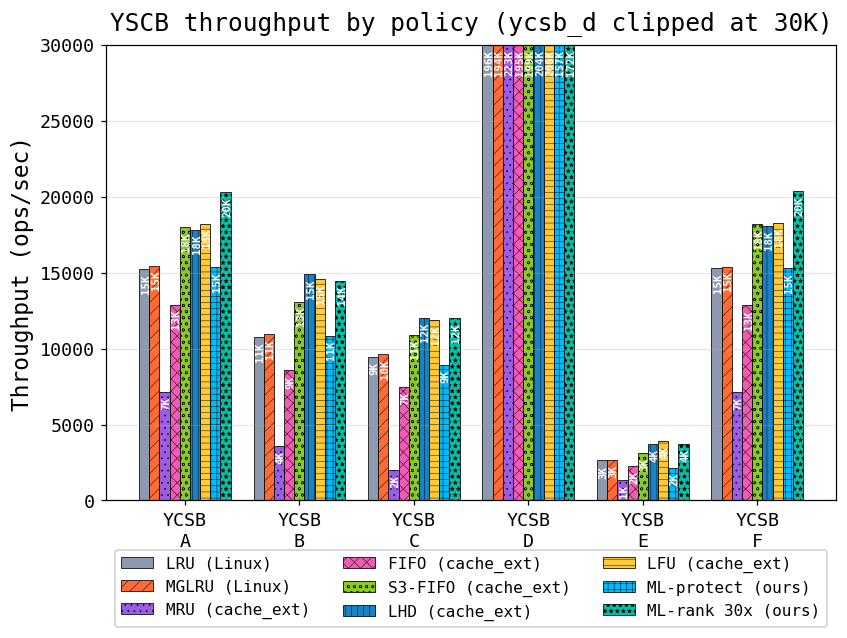

In [3]:
# Throughput by policy, all YCSB workloads (paper bar; white vertical value labels; key below).
import matplotlib.patheffects as pe
HEADLINE = ['Linux LRU', 'MGLRU (Linux)', 'MRU (cache_ext)', 'FIFO (cache_ext)', 'S3-FIFO (cache_ext)',
            'LHD (cache_ext)', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(WORKLOADS)); width = 0.8 / len(HEADLINE)
for i, pol in enumerate(HEADLINE):
    pos = x - 0.4 + width * (i + 0.5)
    vals = tput[pol].values
    bars = ax.bar(pos, vals, width, label=disp(pol), color=COLORS[pol], edgecolor='black', linewidth=0.5, hatch=HATCHES.get(pol, ''))
    for r, v in zip(bars, vals):
        if np.isfinite(v) and v > 0:
            ax.annotate(f'{v/1000:.0f}K', (r.get_x() + r.get_width()/2, min(v, 30000)),
                        ha='right', va='center', rotation=90, rotation_mode='anchor', fontsize=7, color='white',
                        fontweight='bold', xytext=(1, -3), textcoords='offset points')
ax.set_ylim(0, 30000)
ax.set_ylabel('Throughput (ops/sec)')
ax.set_xticks(x); ax.set_xticklabels(WLABELS); ax.grid(axis='x', alpha=0)
ax.set_title('YSCB throughput by policy (ycsb_d clipped at 30K)')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.09))
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig1_throughput_bars.png'))
plt.show()


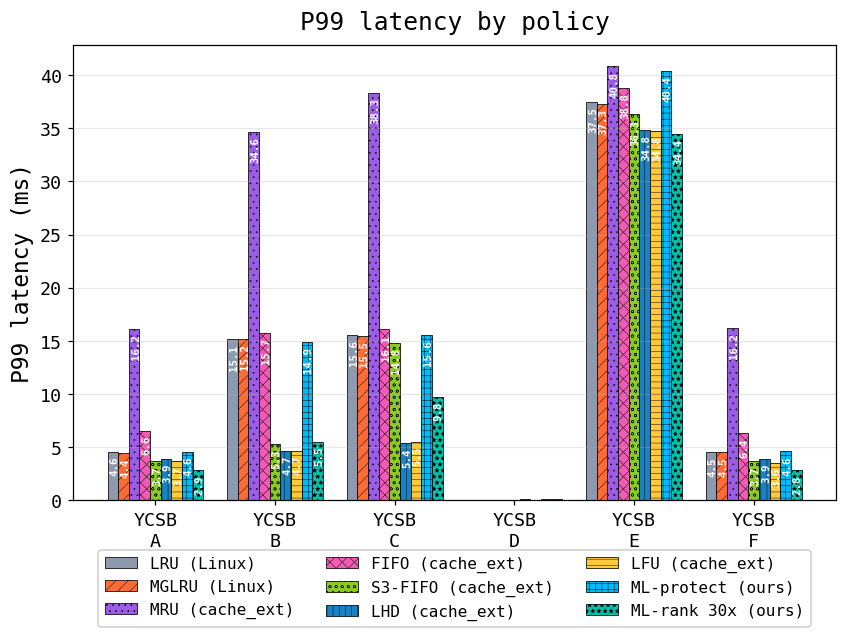

In [4]:
# P99 latency by policy, all YCSB workloads (paper bar; white vertical value labels; key below).
import matplotlib.patheffects as pe
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(WORKLOADS)); width = 0.8 / len(HEADLINE)
for i, pol in enumerate(HEADLINE):
    pos = x - 0.4 + width * (i + 0.5)
    vals = p99[pol].values
    bars = ax.bar(pos, vals, width, label=disp(pol), color=COLORS[pol], edgecolor='black', linewidth=0.5, hatch=HATCHES.get(pol, ''))
    for r, v in zip(bars, vals):
        if np.isfinite(v) and v > 0.4:
            ax.annotate(f'{v:.1f}', (r.get_x() + r.get_width()/2, v),
                        ha='right', va='center', rotation=90, rotation_mode='anchor', fontsize=7, color='white',
                        fontweight='bold', xytext=(1, -3), textcoords='offset points')
ax.set_ylabel('P99 latency (ms)')
ax.set_xticks(x); ax.set_xticklabels(WLABELS); ax.grid(axis='x', alpha=0)
ax.set_title('P99 latency by policy')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.09))
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig2_p99_bars.png'))
plt.show()


## Oversampling-factor sweep
ML-rank throughput (normalized to the best classical cache_ext policy per
workload) across sample_size 10/20/30/40. Above the red line = beats every
classical policy.

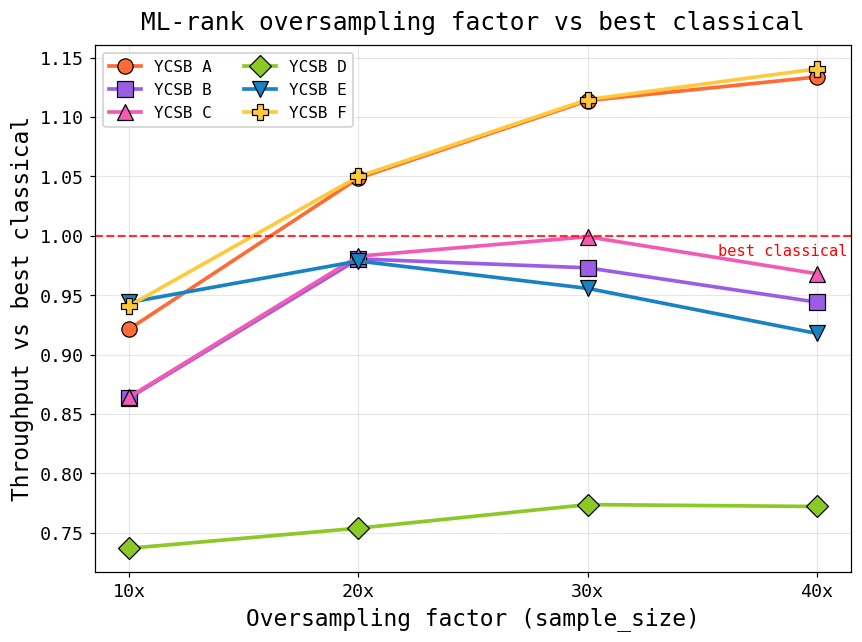

In [5]:
FACTORS = [10, 20, 30, 40]
RANK_LABELS = {f: f'ML-rank {f}x (ours)' for f in FACTORS}
wl_colors = ['#FF6B35', '#9B5DE5', '#F15BB5', '#8AC926', '#1982C4', '#FFCA3A']
wl_markers = ['o', 's', '^', 'D', 'v', 'P']  # distinct shapes -> readable in greyscale

fig, ax = plt.subplots(figsize=(8, 6))
for w, wl, c, mk in zip(WORKLOADS, WLABELS, wl_colors, wl_markers):
    rel = [tput.loc[w, RANK_LABELS[f]] / best_classical[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker=mk, markersize=10, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.annotate('best classical', xy=(0.995, 1.0), xycoords=ax.get_yaxis_transform(),
            xytext=(0, -5), textcoords='offset points',
            color='red', fontsize=10, ha='right', va='top')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs best classical')
ax.set_title('ML-rank oversampling factor vs best classical')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3_oversampling_sweep.png'))
plt.show()

### Same sweep, normalized to FIFO
Both ML variants are built on top of FIFO (protect = FIFO order + model skip,
rank = FIFO list + sampled model scoring), so FIFO is the ablation base: this
is the pure value-added of the model.

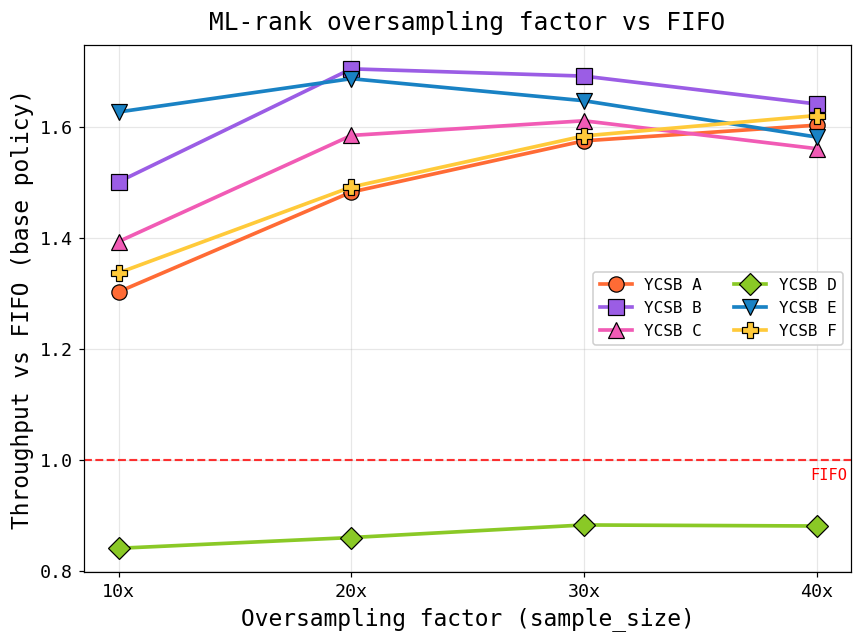

In [6]:
fifo = tput['FIFO (cache_ext)']

fig, ax = plt.subplots(figsize=(8, 6))
for w, wl, c, mk in zip(WORKLOADS, WLABELS, wl_colors, wl_markers):
    rel = [tput.loc[w, RANK_LABELS[f]] / fifo[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker=mk, markersize=10, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.annotate('FIFO', xy=(0.995, 1.0), xycoords=ax.get_yaxis_transform(),
            xytext=(0, -5), textcoords='offset points',
            color='red', fontsize=10, ha='right', va='top')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs FIFO (base policy)')
ax.set_title('ML-rank oversampling factor vs FIFO')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3b_oversampling_sweep_vs_fifo.png'))
plt.show()

### Same sweep, normalized to Linux MGLRU
The deployment view: gain over the stock kernel default at each factor.

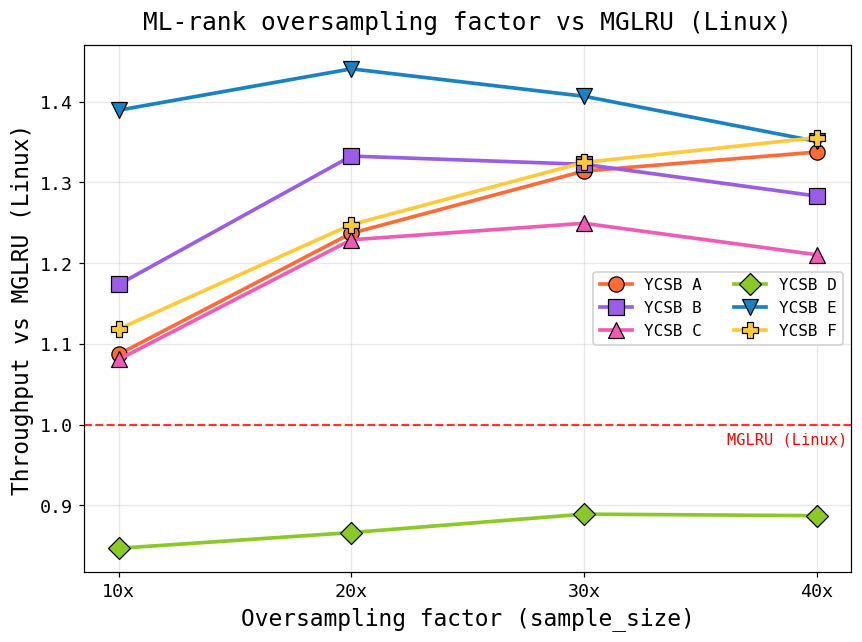

In [7]:
mglru_base = tput['MGLRU (Linux)']

fig, ax = plt.subplots(figsize=(8, 6))
for w, wl, c, mk in zip(WORKLOADS, WLABELS, wl_colors, wl_markers):
    rel = [tput.loc[w, RANK_LABELS[f]] / mglru_base[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker=mk, markersize=10, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.annotate('MGLRU (Linux)', xy=(0.995, 1.0), xycoords=ax.get_yaxis_transform(),
            xytext=(0, -5), textcoords='offset points',
            color='red', fontsize=10, ha='right', va='top')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs MGLRU (Linux)')
ax.set_title('ML-rank oversampling factor vs MGLRU (Linux)')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3c_oversampling_sweep_vs_mglru.png'))
plt.show()

## Normalized-throughput heatmap
Every policy on every workload, normalized to the best **baseline** of that
workload — the best classical cache_ext policy *or* Linux LRU/MGLRU, whichever
is higher (1.00 = matches the best existing option; greener = better).

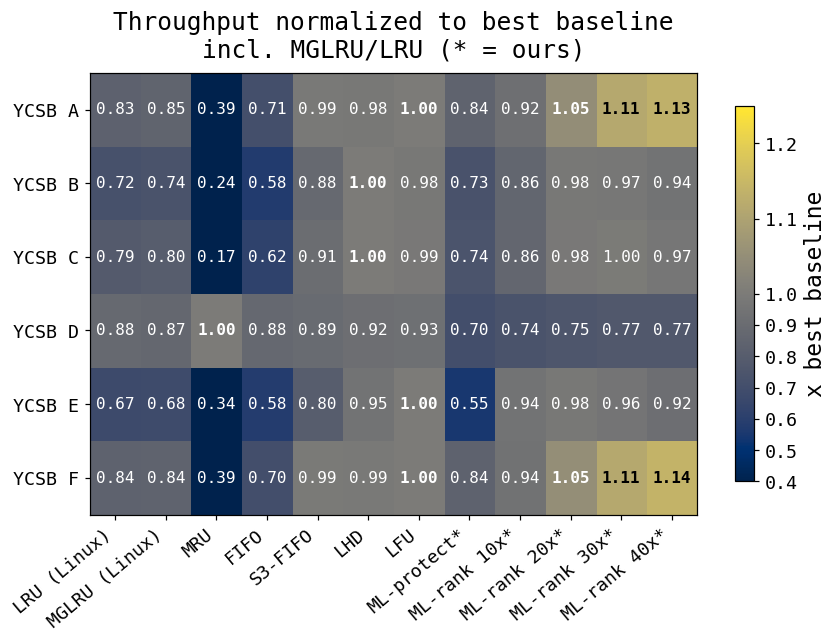

In [8]:
HEAT_POLS = ['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)'] + \
            [RANK_LABELS[f] for f in FACTORS]
best_baseline = tput[[p for p in CLASSICAL + ['MGLRU (Linux)', 'Linux LRU']
                      if p in tput.columns]].max(axis=1)
norm = (tput[HEAT_POLS].T / best_baseline).T

with plt.rc_context({'axes.grid': False}):  # grids would fight imshow + colorbar
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(norm.values, cmap='cividis',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.25),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm.shape[0]):
        for j in range(norm.shape[1]):
            v = norm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to best baseline\nincl. MGLRU/LRU (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x best baseline')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5_normalized_heatmap.png'))
    plt.show()

### Same heatmap, normalized to FIFO
Value-added view: how much each policy gains (or loses) relative to plain
FIFO — the base both ML variants are built on. Diverging scale centered at
1.0 (= FIFO parity).

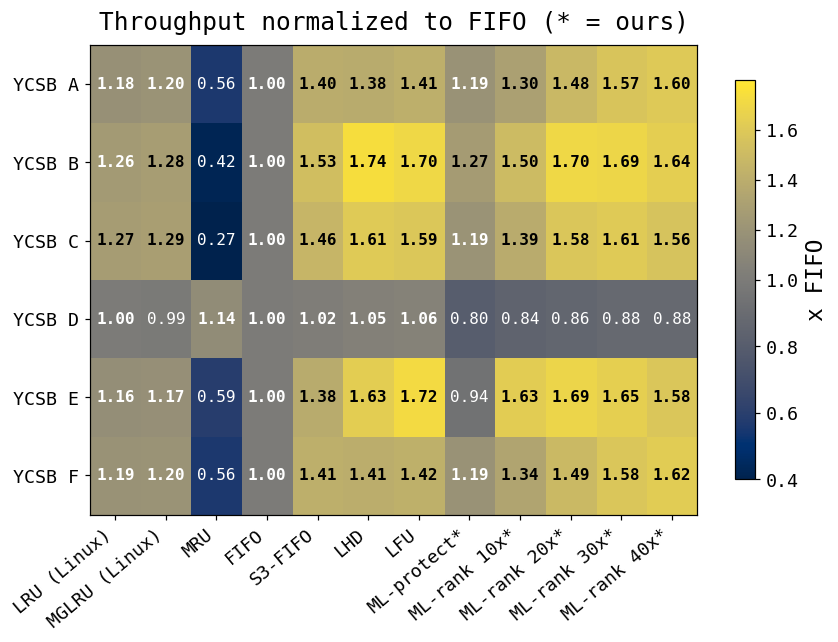

In [9]:
from matplotlib.colors import TwoSlopeNorm

norm_fifo = (tput[HEAT_POLS].T / fifo).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(norm_fifo.values, cmap='cividis',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.8),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm_fifo.shape[0]):
        for j in range(norm_fifo.shape[1]):
            v = norm_fifo.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to FIFO (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x FIFO')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5b_normalized_heatmap_vs_fifo.png'))
    plt.show()

### Same heatmap, normalized to Linux MGLRU
Deployment view: red cells would lose throughput versus simply running the
stock kernel default.

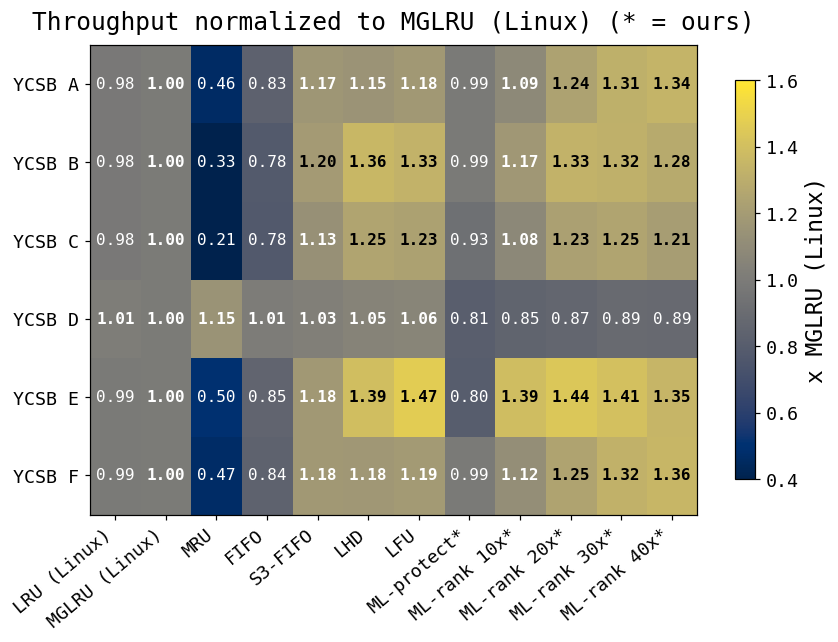

In [10]:
norm_mglru = (tput[HEAT_POLS].T / mglru_base).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(norm_mglru.values, cmap='cividis',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.6),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm_mglru.shape[0]):
        for j in range(norm_mglru.shape[1]):
            v = norm_mglru.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to MGLRU (Linux) (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x MGLRU (Linux)')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5c_normalized_heatmap_vs_mglru.png'))
    plt.show()

### Same heatmap, normalized to the best cache_ext classical policy only
Excludes the kernel baselines (Linux LRU/MGLRU) from the reference — the bar is
the best of MRU/FIFO/S3-FIFO/LHD/LFU alone.

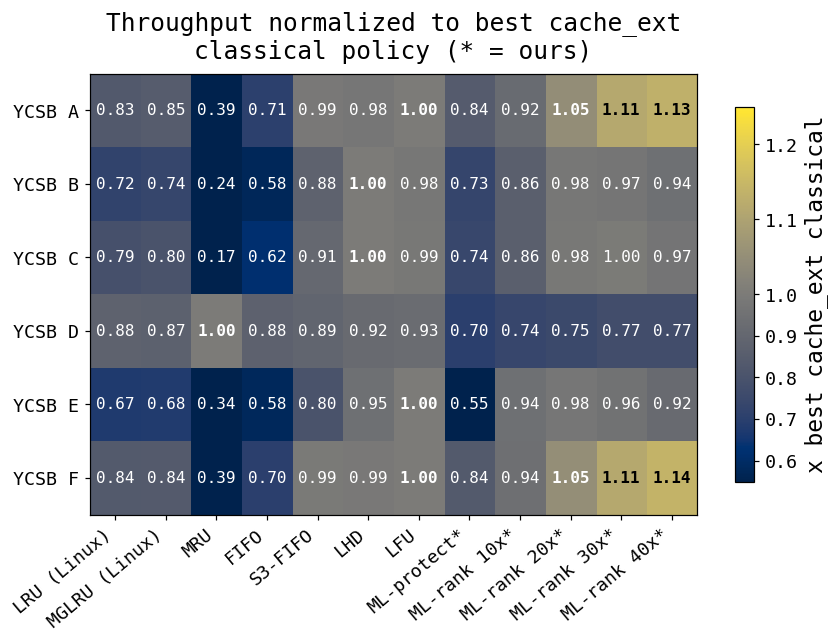

In [11]:
# Same heatmap, normalized to the best cache_ext classical policy ONLY (no kernel baselines).
norm_cc = (tput[HEAT_POLS].T / best_classical).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(norm_cc.values, cmap='cividis',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.25), aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm_cc.shape[0]):
        for j in range(norm_cc.shape[1]):
            v = norm_cc.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to best cache_ext\nclassical policy (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x best cache_ext classical')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5d_normalized_heatmap_best_cache_ext_classical.png'))
    plt.show()

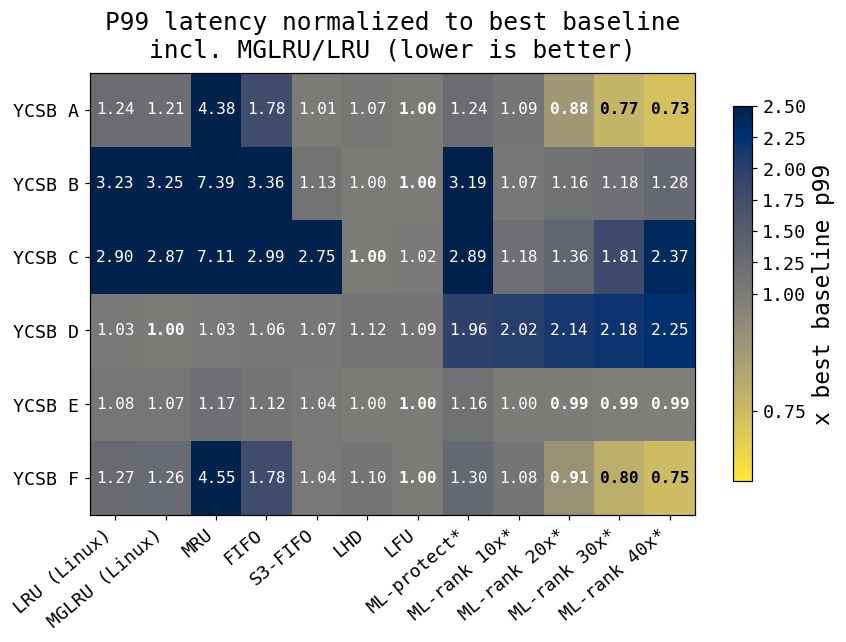

In [12]:
# P99 latency heatmap, normalized to best baseline (incl. MGLRU/LRU). LOWER is better, so cividis is reversed (light = lower latency = good),
# mirroring the throughput heatmaps where light = better.
p99m = p99.replace(0.0, np.nan)  # drop missing/zero p99 (e.g. ycsb_d) so they blank out
best_baseline_p99 = p99m[[p for p in CLASSICAL + ['MGLRU (Linux)', 'Linux LRU']
                          if p in p99m.columns]].min(axis=1)
pnorm = (p99m[HEAT_POLS].T / best_baseline_p99).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pnorm.values, cmap='cividis_r',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.6, vmax=2.5),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(pnorm.shape[0]):
        for j in range(pnorm.shape[1]):
            v = pnorm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v <= 1.0 else 'normal')
    ax.set_title('P99 latency normalized to best baseline\nincl. MGLRU/LRU (lower is better)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x best baseline p99')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig6_p99_heatmap.png'))
    plt.show()


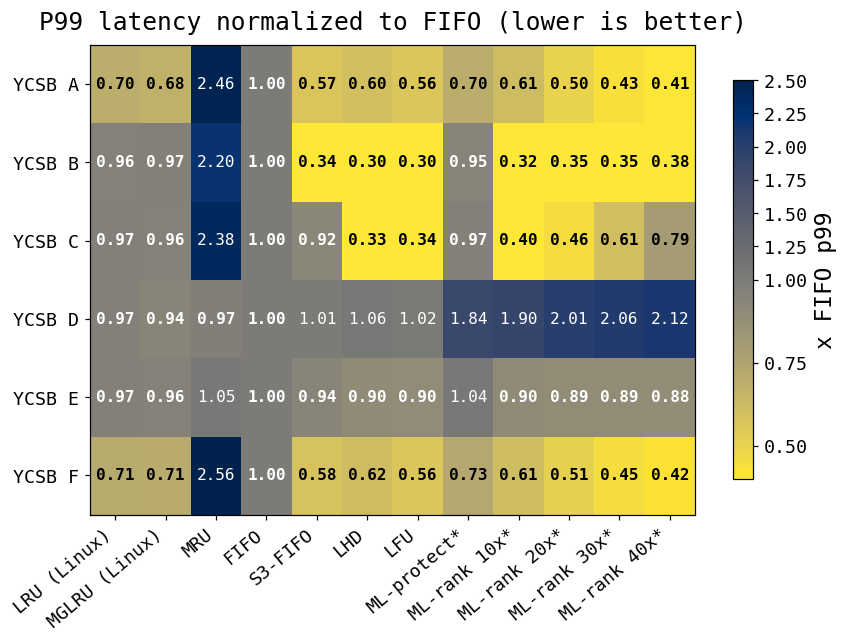

In [13]:
# P99 latency heatmap, normalized to FIFO (the ML base policy). LOWER is better, so cividis is reversed (light = lower latency = good),
# mirroring the throughput heatmaps where light = better.
fifo_p99 = p99m['FIFO (cache_ext)']
pnorm = (p99m[HEAT_POLS].T / fifo_p99).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pnorm.values, cmap='cividis_r',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=2.5),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(pnorm.shape[0]):
        for j in range(pnorm.shape[1]):
            v = pnorm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v <= 1.0 else 'normal')
    ax.set_title('P99 latency normalized to FIFO (lower is better)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x FIFO p99')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig6b_p99_heatmap_vs_fifo.png'))
    plt.show()


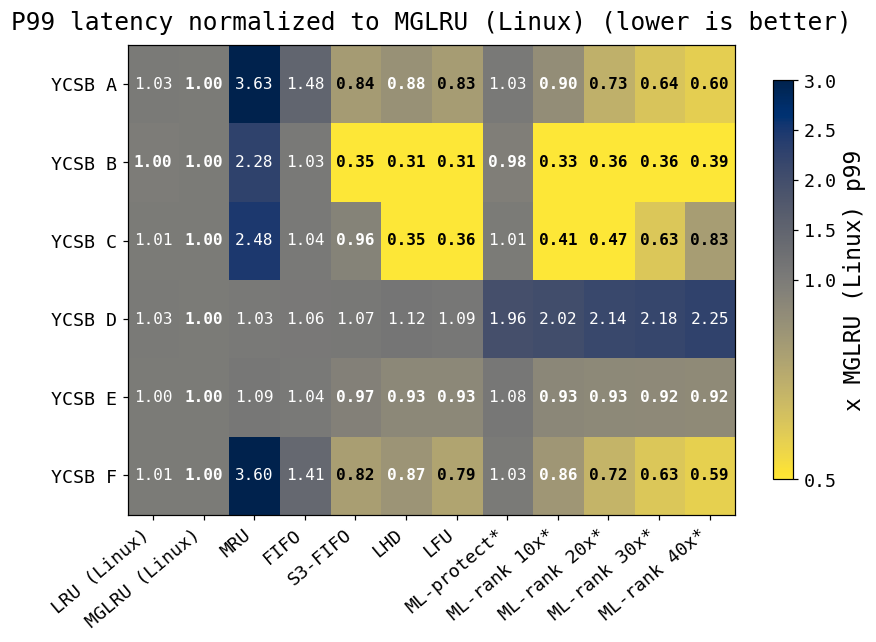

In [14]:
# P99 latency heatmap, normalized to MGLRU (Linux). LOWER is better, so cividis is reversed (light = lower latency = good),
# mirroring the throughput heatmaps where light = better.
mglru_p99 = p99m['MGLRU (Linux)']
pnorm = (p99m[HEAT_POLS].T / mglru_p99).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pnorm.values, cmap='cividis_r',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.5, vmax=3.0),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(pnorm.shape[0]):
        for j in range(pnorm.shape[1]):
            v = pnorm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v <= 1.0 else 'normal')
    ax.set_title('P99 latency normalized to MGLRU (Linux) (lower is better)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x MGLRU (Linux) p99')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig6c_p99_heatmap_vs_mglru.png'))
    plt.show()


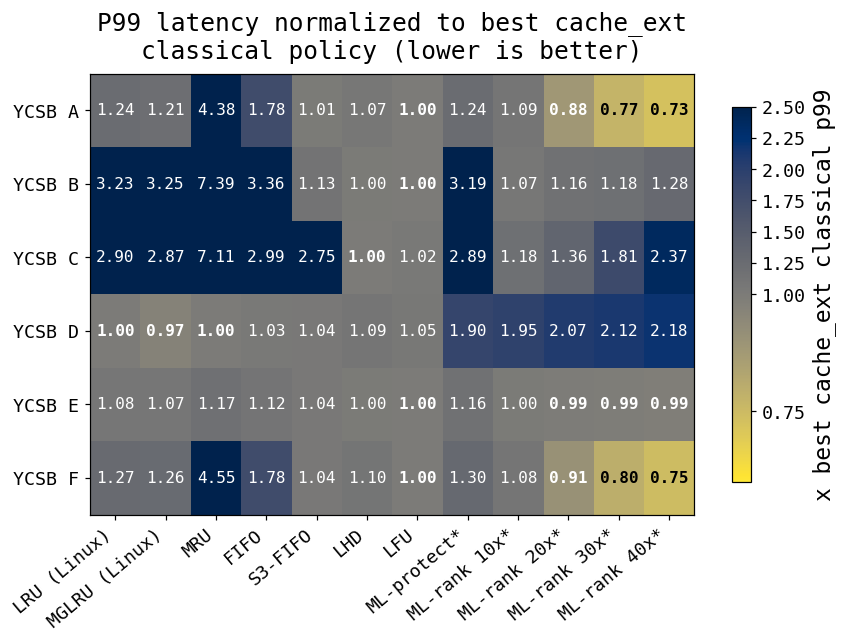

In [15]:
# P99 latency heatmap, normalized to best cache_ext classical policy ONLY (no kernel baselines). LOWER is better, so cividis is reversed (light = lower latency = good),
# mirroring the throughput heatmaps where light = better.
best_classical_p99 = p99m[[p for p in CLASSICAL if p in p99m.columns]].min(axis=1)
pnorm = (p99m[HEAT_POLS].T / best_classical_p99).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pnorm.values, cmap='cividis_r',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.6, vmax=2.5),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                        for p in HEAT_POLS], rotation=40, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(pnorm.shape[0]):
        for j in range(pnorm.shape[1]):
            v = pnorm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v <= 1.0 else 'normal')
    ax.set_title('P99 latency normalized to best cache_ext\nclassical policy (lower is better)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x best cache_ext classical p99')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig6d_p99_heatmap_best_cache_ext_classical.png'))
    plt.show()


## Per-operation tail latency
READ vs UPDATE p99 for the key policies (workloads that issue both op types).
Checks that ML-rank's throughput wins aren't bought with one op type's tail.

## Speedup over Linux MGLRU
The deployment question: what do you gain over the stock kernel default?

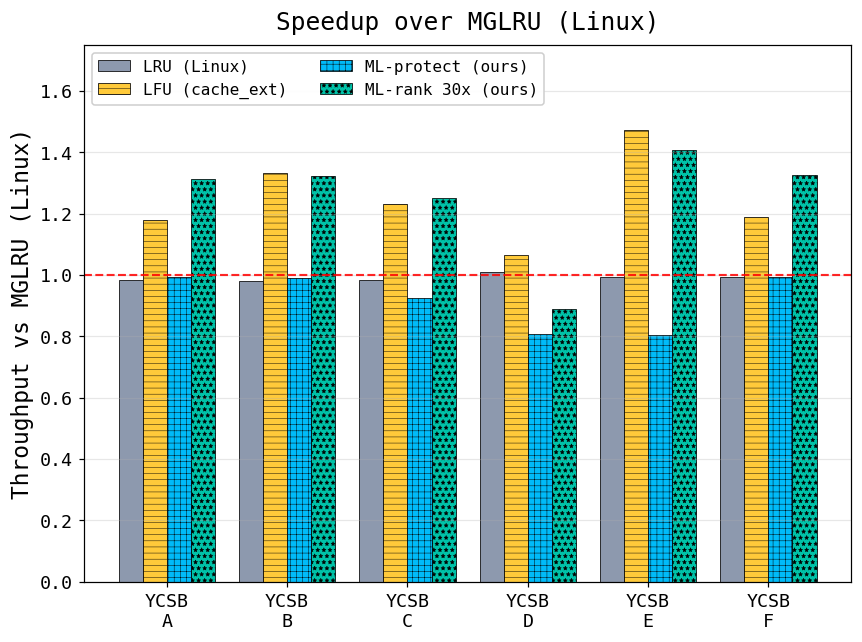

In [16]:
# Speedup over Linux MGLRU per YCSB workload (paper bar; inset key, no per-bar labels).
SPEED_POLS = ['Linux LRU', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
mglru = tput['MGLRU (Linux)']
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(WORKLOADS)); width = 0.8 / len(SPEED_POLS)
for i, pol in enumerate(SPEED_POLS):
    pos = x - 0.4 + width * (i + 0.5)
    ax.bar(pos, (tput[pol] / mglru).values, width, label=disp(pol), color=COLORS[pol],
           edgecolor='black', linewidth=0.5, hatch=HATCHES.get(pol, ''))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.85)
ax.set_ylim(0, 1.75)
ax.set_xticks(x); ax.set_xticklabels(WLABELS)
ax.set_ylabel('Throughput vs MGLRU (Linux)')
ax.set_title('Speedup over MGLRU (Linux)')
ax.legend(ncol=2, loc='upper left', framealpha=0.95)
ax.grid(axis='x', alpha=0)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig7_speedup_vs_mglru.png'))
plt.show()

## Eviction-decision latency
Raw per-call `evict_folios` durations (one `bpf_printk` sample per eviction
batch, captured from trace_pipe during short ycsb_a runs; 100k–255k samples
per policy). Parsed directly from the raw ftrace files
`results/evict_latency/<tag>.trace` (one `bpf_trace_printk: evict_lat_ns=<delta>`
line per `evict_folios` call) — see the loader in the next cell.

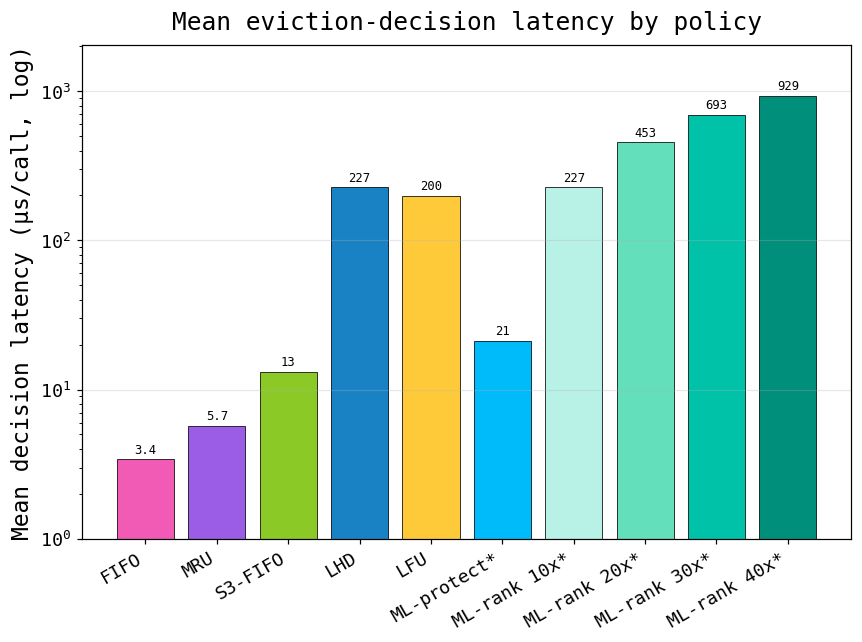

In [17]:
# Load raw per-call samples and plot the latency CDF (log x) per policy.
LAT_DIR = os.path.join(RES, 'evict_latency')
LAT_TAGS = {   # tag -> (label, color)
    'fifo':      ('FIFO (cache_ext)',    COLORS['FIFO (cache_ext)']),
    'mru':       ('MRU (cache_ext)',     COLORS['MRU (cache_ext)']),
    's3fifo':    ('S3-FIFO (cache_ext)', COLORS['S3-FIFO (cache_ext)']),
    'lhd':       ('LHD (cache_ext)',     COLORS['LHD (cache_ext)']),
    'sampling':  ('LFU (cache_ext)',     COLORS['LFU (cache_ext)']),
    'mlprotect': ('ML-protect (ours)',   COLORS['ML-protect (ours)']),
    'ml10':      ('ML-rank 10x (ours)',  COLORS['ML-rank 10x (ours)']),
    'ml20':      ('ML-rank 20x (ours)',  COLORS['ML-rank 20x (ours)']),
    'ml30':      ('ML-rank 30x (ours)',  COLORS['ML-rank 30x (ours)']),
    'ml40':      ('ML-rank 40x (ours)',  COLORS['ML-rank 40x (ours)']),
}
# Parse the raw ftrace .trace files directly (one bpf_printk per
# evict_folios call: "... <ts>: bpf_trace_printk: evict_lat_ns=<delta>").
import re
_LAT_RE = re.compile(r'\s(\d+\.\d+):\s+\S+\s+evict_lat_ns=(\d+)')
def _trace_latency_us(path):
    if not os.path.exists(path):
        return None
    vals = []
    with open(path, errors='replace') as f:
        for line in f:
            m = _LAT_RE.search(line)
            if m:
                vals.append(int(m.group(2)) / 1000.0)
    return np.array(vals) if vals else None

lat_us = {}
for tag in LAT_TAGS:
    arr = _trace_latency_us(os.path.join(LAT_DIR, f'{tag}.trace'))
    if arr is not None:
        lat_us[tag] = arr

tags = [t for t in LAT_TAGS if t in lat_us]
means = [float(np.mean(lat_us[t])) for t in tags]
bar_colors = [LAT_TAGS[t][1] for t in tags]
bar_labels = [LAT_TAGS[t][0].replace(' (cache_ext)', '').replace(' (ours)', '*') for t in tags]
fig, ax = plt.subplots(figsize=(8, 6))
xpos = np.arange(len(tags))
bars = ax.bar(xpos, means, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_yscale('log')
ax.set_ylim(1, max(means) * 2.2)
for r, m in zip(bars, means):
    ax.annotate(f'{m:.1f}' if m < 10 else f'{m:.0f}', (r.get_x() + r.get_width()/2, m),
                ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')
ax.set_xticks(xpos); ax.set_xticklabels(bar_labels, rotation=30, ha='right')
ax.grid(axis='x', alpha=0)
ax.set_ylabel('Mean decision latency (µs/call, log)')
ax.set_title('Mean eviction-decision latency by policy')
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig8_evict_latency_bars.png'))
plt.show()


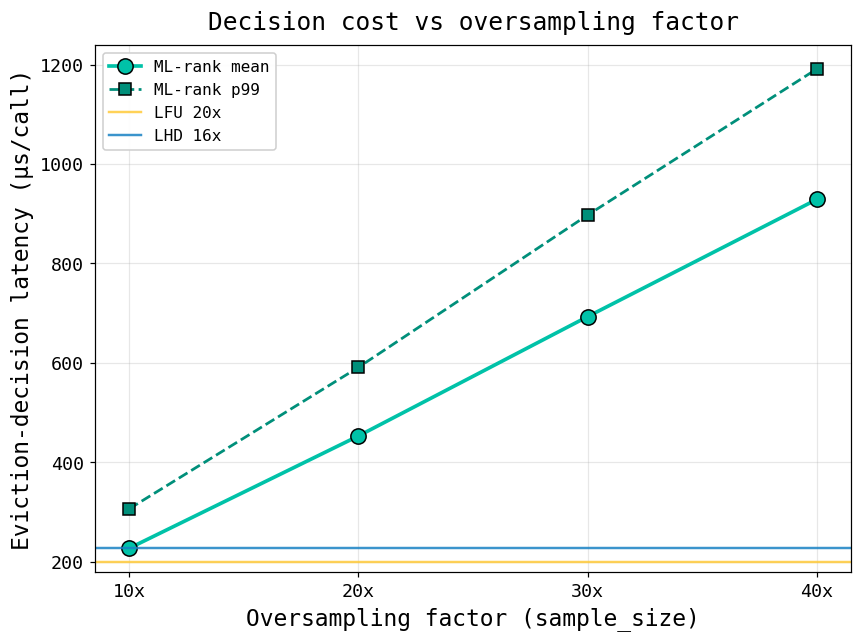

In [18]:
# ML-rank cost scales linearly with the oversampling factor (~0.7 µs per
# scored folio: factor x 32 victims folios per call). LFU/LHD shown as
# same-machinery reference lines.
factors = np.array(FACTORS)
means = np.array([np.mean(lat_us[f'ml{f}']) for f in factors])
p99s = np.array([np.percentile(lat_us[f'ml{f}'], 99) for f in factors])
slope, intercept = np.polyfit(factors, means, 1)
per_folio_us = slope / 32  # 32-victim batches

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(factors, means, marker='o', markersize=10, linewidth=2.4,
        color='#00C2A8', markeredgecolor='black', label='ML-rank mean')
ax.plot(factors, p99s, marker='s', markersize=8, linewidth=1.8,
        linestyle='--', color='#008F7A', markeredgecolor='black',
        label='ML-rank p99')
for ref, color, lab in (('sampling', COLORS['LFU (cache_ext)'], 'LFU 20x'),
                        ('lhd', COLORS['LHD (cache_ext)'], 'LHD 16x')):
    ax.axhline(np.mean(lat_us[ref]), color=color, linewidth=1.6, alpha=0.85, label=lab)
ax.set_xticks(factors); ax.set_xticklabels([f'{f}x' for f in factors])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Eviction-decision latency (µs/call)')
ax.set_title('Decision cost vs oversampling factor')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig9_evict_latency_scaling.png'))
plt.show()

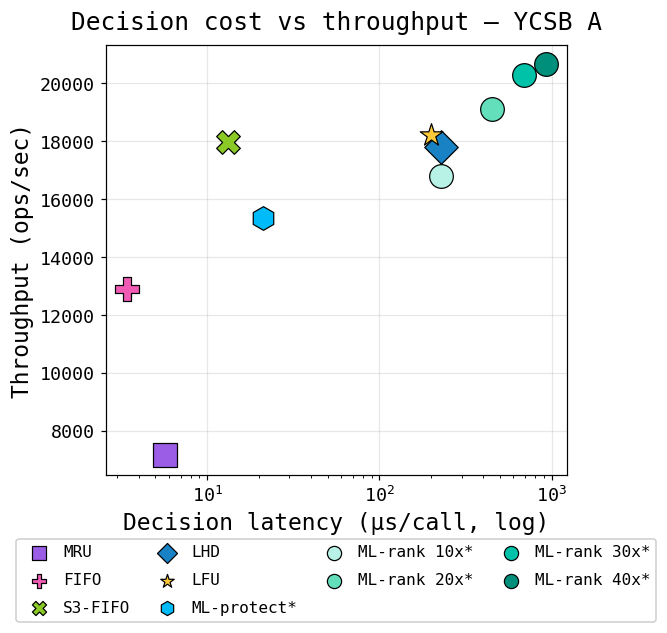

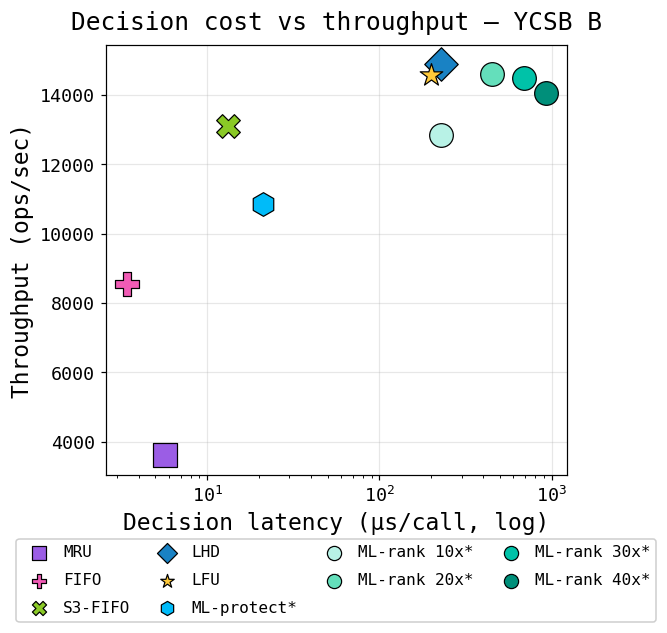

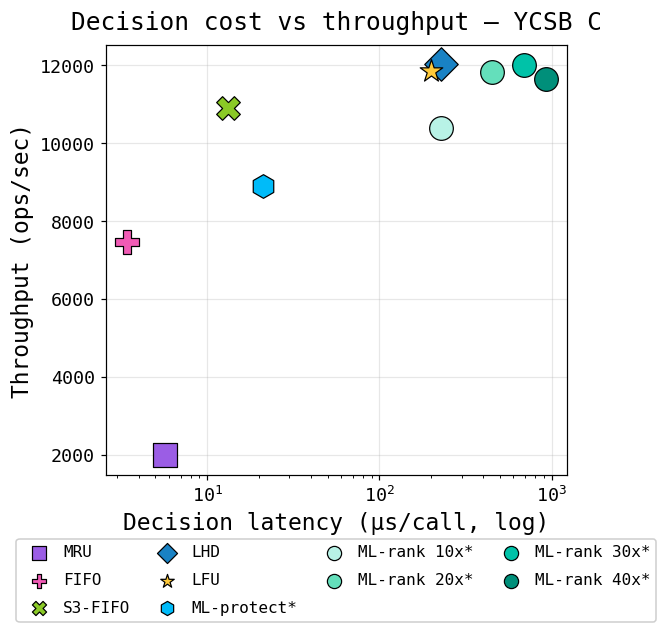

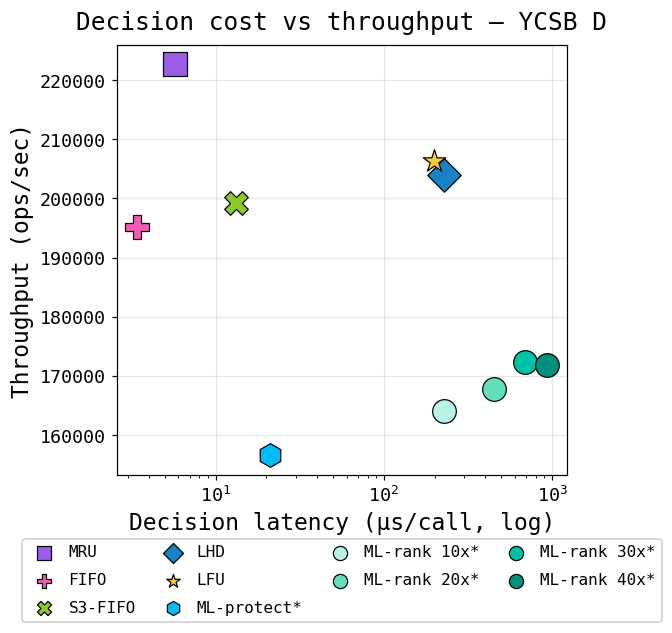

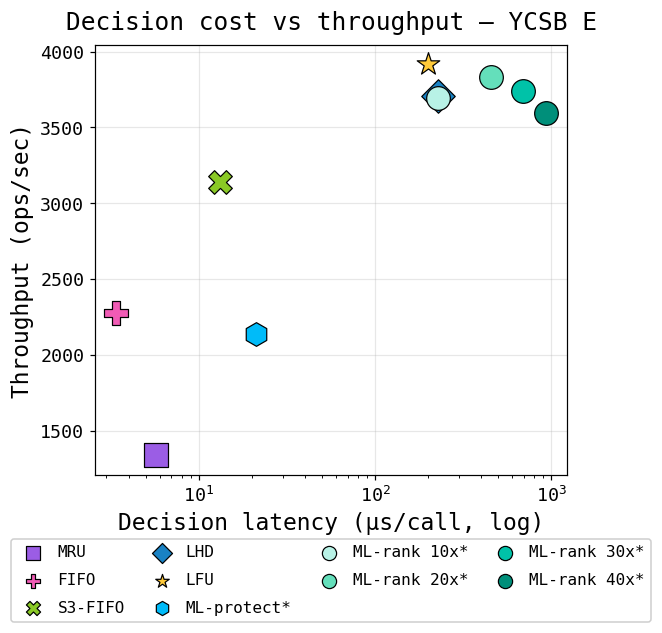

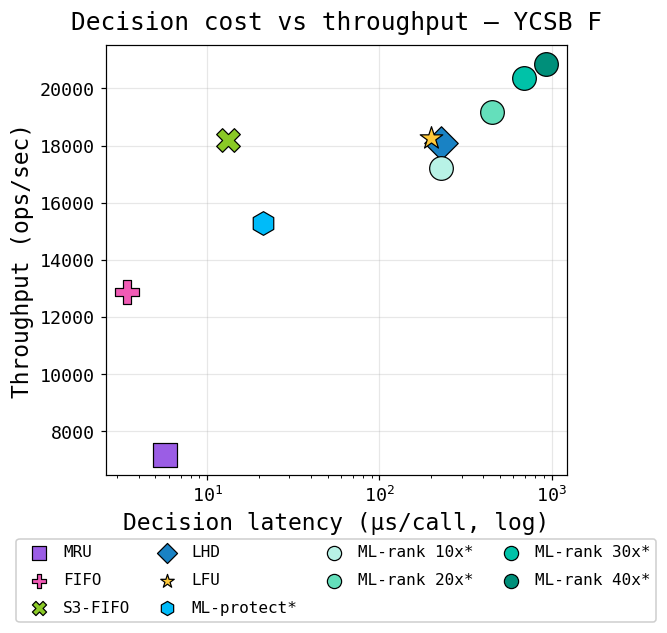

In [19]:
# Decision cost vs delivered throughput -> individual per-YCSB-workload panels in a subdir.
PAIR = {'mru': 'MRU (cache_ext)', 'fifo': 'FIFO (cache_ext)',
        's3fifo': 'S3-FIFO (cache_ext)', 'lhd': 'LHD (cache_ext)',
        'sampling': 'LFU (cache_ext)', 'mlprotect': 'ML-protect (ours)',
        'ml10': 'ML-rank 10x (ours)', 'ml20': 'ML-rank 20x (ours)',
        'ml30': 'ML-rank 30x (ours)', 'ml40': 'ML-rank 40x (ours)'}
pairs = [(t, c) for t, c in PAIR.items() if t in lat_us and c in tput.columns]
SUBDIR = os.path.join(FIGS, 'fig10_cost_vs_throughput')
os.makedirs(SUBDIR, exist_ok=True)
for wl in WORKLOADS:
    fig, ax = plt.subplots(figsize=(6, 6))
    for tag, col in pairs:
        y = tput.loc[wl, col]
        if not np.isfinite(y):
            continue
        ax.scatter(np.mean(lat_us[tag]), y, s=240, color=COLORS[col],
                   marker=MARKERS.get(col, 'o'), edgecolor='black', linewidth=0.8, zorder=3,
                   label=col.replace(' (cache_ext)', '').replace(' (ours)', '*'))
    ax.set_xscale('log')
    ax.set_title('Decision cost vs throughput — ' + wl.replace('ycsb_', 'YCSB ').upper())
    ax.set_xlabel('Decision latency (µs/call, log)')
    ax.set_ylabel('Throughput (ops/sec)')
    ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.13),
              markerscale=0.6, labelspacing=0.8, columnspacing=1.3, handletextpad=0.5)
    fig.tight_layout()
    fig.savefig(os.path.join(SUBDIR, wl.replace('ycsb_', 'YCSB_').upper() + '.png'))
    plt.show()


## Twitter cluster benchmark results

Production Twitter cache traces (paper Fig 8), clusters 17/18/24/34/52, replayed
against per-cluster LevelDB DBs. **Throughput-only** — the `leveldb-latency`
My-YCSB branch disables per-op latency, so only the throughput / speedup /
normalized views below apply (there is no p99 panel).

Populate `results/twitter_eval_*.json` with `lc-eval/twitter/reproduce_eval.sh`
(needs per-cluster models). Until then the cells below print a notice and skip.

In [20]:
# --- Twitter results -> tidy DataFrame (mirrors the ycsb loader) ---
TWITTER_CLUSTERS = [17, 18, 24, 34, 52]
TWITTER_WL = [f'twitter_cluster{c}_bench' for c in TWITTER_CLUSTERS]
TWITTER_WLABELS = [f'C{c}' for c in TWITTER_CLUSTERS]

def twitter_rows_from(path, ml_label=None, baseline_label='MGLRU (Linux)'):
    if not os.path.exists(path):
        return []
    out = []
    for e in json.load(open(path)):
        cfg, res = e['config'], e['results']
        w = cfg.get('benchmark')
        if w not in TWITTER_WL:
            continue
        if cfg.get('cgroup_name') == 'baseline_test':
            label = baseline_label
        else:
            loader = cfg.get('policy_loader')
            label = (ml_label if loader == 'cache_ext_ml_sampling.out'
                     else LOADER_LABEL.get(loader))
        if not label:
            continue
        out.append({'workload': w, 'policy': label, 'tput': res.get('throughput_avg')})
    return out

tdf = pd.DataFrame(
    twitter_rows_from(os.path.join(RES, 'twitter_eval_results.json'))
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_protect.json'))
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_lru.json'), baseline_label='Linux LRU')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_mglru.json'))
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml10.json'), 'ML-rank 10x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml20.json'), 'ML-rank 20x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml30.json'), 'ML-rank 30x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml40.json'), 'ML-rank 40x (ours)'))

TWITTER_OK = not tdf.empty
if not TWITTER_OK:
    ttput = None
    print('No Twitter results yet - run lc-eval/twitter/reproduce_eval.sh to populate '
          'results/twitter_eval_*.json, then re-run this notebook.')
else:
    # average across iterations -> one value per (cluster, policy)
    ttput = (tdf.groupby(['workload', 'policy'])['tput'].mean()
                .unstack('policy').reindex(TWITTER_WL))
    print(f'{len(tdf)} rows, {tdf.policy.nunique()} policies x {tdf.workload.nunique()} clusters')
    display(ttput.round(0))

40 rows, 8 policies x 5 clusters


policy,FIFO (cache_ext),LFU (cache_ext),LHD (cache_ext),Linux LRU,MGLRU (Linux),ML-protect (ours),MRU (cache_ext),S3-FIFO (cache_ext)
workload,,,,,,,,
twitter_cluster17_bench,77258.0,88697.0,84539.0,92918.0,100224.0,91305.0,90072.0,87548.0
twitter_cluster18_bench,81241.0,91341.0,84115.0,98540.0,99811.0,105270.0,80061.0,86543.0
twitter_cluster24_bench,61970.0,66124.0,64381.0,69027.0,74649.0,67724.0,67586.0,56934.0
twitter_cluster34_bench,19019.0,21252.0,22024.0,21978.0,16692.0,23679.0,17068.0,23258.0
twitter_cluster52_bench,44212.0,55292.0,53632.0,51953.0,37480.0,55525.0,53328.0,49611.0


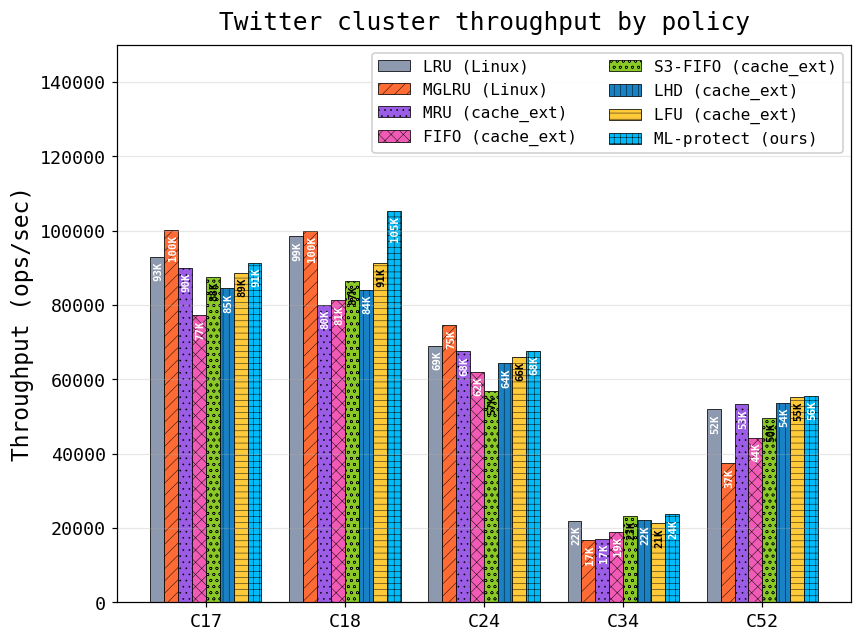

In [21]:
# Twitter per-cluster throughput bars (paper bar; white vertical value labels; inset key).
import matplotlib.patheffects as pe
if not TWITTER_OK:
    print('No Twitter results - skipping throughput figure.')
else:
    TW_HEADLINE = ['Linux LRU', 'MGLRU (Linux)', 'MRU (cache_ext)', 'FIFO (cache_ext)',
                   'S3-FIFO (cache_ext)', 'LHD (cache_ext)', 'LFU (cache_ext)',
                   'ML-protect (ours)', 'ML-rank 30x (ours)']
    pols = [p for p in TW_HEADLINE if p in ttput.columns]
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(TWITTER_WL)); width = 0.8 / max(len(pols), 1)
    for i, pol in enumerate(pols):
        pos = x - 0.4 + width * (i + 0.5)
        vals = ttput[pol].reindex(TWITTER_WL).values
        bars = ax.bar(pos, vals, width, label=disp(pol), color=COLORS.get(pol), edgecolor='black', linewidth=0.5, hatch=HATCHES.get(pol, ''))
        for r, v in zip(bars, vals):
            if np.isfinite(v) and v > 0:
                ax.annotate(f'{v/1000:.0f}K', (r.get_x() + r.get_width()/2, v),
                            ha='right', va='center', rotation=90, rotation_mode='anchor', fontsize=7, color=text_on(COLORS[pol]),
                            fontweight='bold', xytext=(1, -3), textcoords='offset points')
    ax.set_ylim(0, 150000)
    ax.set_ylabel('Throughput (ops/sec)')
    ax.set_xticks(x); ax.set_xticklabels(TWITTER_WLABELS)
    ax.set_title('Twitter cluster throughput by policy')
    ax.legend(ncol=2, loc='upper right', framealpha=0.95)
    ax.grid(axis='x', alpha=0)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig11_twitter_throughput.png'))
    plt.show()


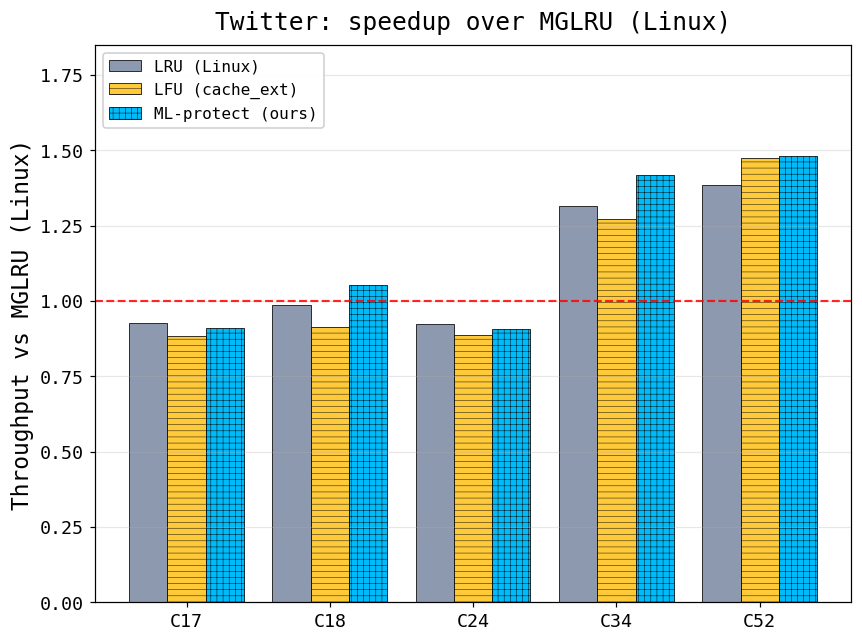

In [22]:
# Twitter speedup over Linux MGLRU (paper bar; inset key).
if not TWITTER_OK:
    print('No Twitter results - skipping speedup figure.')
elif 'MGLRU (Linux)' not in ttput.columns:
    print('No MGLRU baseline rows - skipping speedup figure.')
else:
    SPEED_POLS = [p for p in ['Linux LRU', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
                  if p in ttput.columns]
    mglru = ttput['MGLRU (Linux)'].reindex(TWITTER_WL)
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(TWITTER_WL)); width = 0.8 / max(len(SPEED_POLS), 1)
    for i, pol in enumerate(SPEED_POLS):
        pos = x - 0.4 + width * (i + 0.5)
        ax.bar(pos, (ttput[pol].reindex(TWITTER_WL) / mglru).values, width, label=disp(pol),
               color=COLORS.get(pol), edgecolor='black', linewidth=0.5, hatch=HATCHES.get(pol, ''))
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.85)
    ax.set_ylim(0, 1.85)
    ax.set_xticks(x); ax.set_xticklabels(TWITTER_WLABELS)
    ax.set_ylabel('Throughput vs MGLRU (Linux)')
    ax.set_title('Twitter: speedup over MGLRU (Linux)')
    ax.legend(ncol=1, loc='upper left', framealpha=0.95)
    ax.grid(axis='x', alpha=0)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig12_twitter_speedup_vs_mglru.png'))
    plt.show()

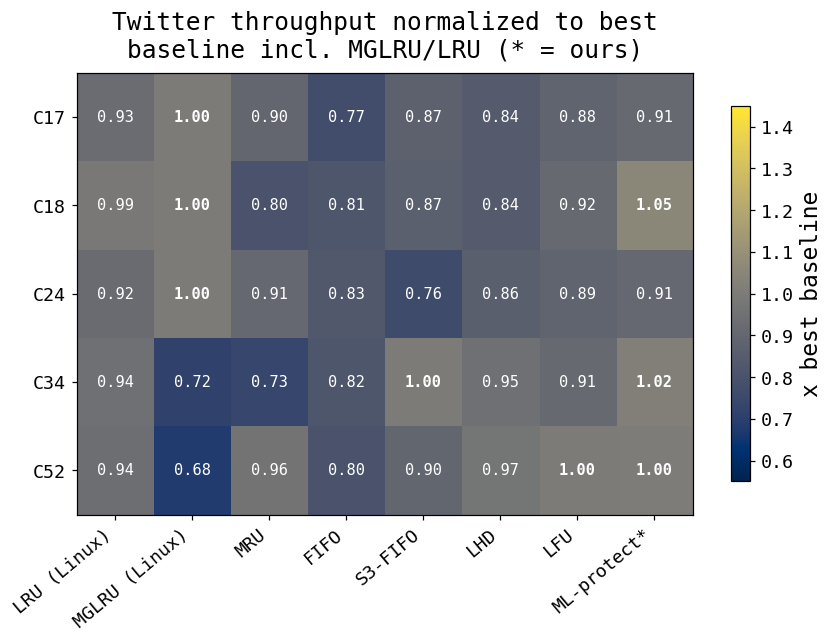

In [23]:
# Twitter throughput heatmap, normalized to best baseline (incl MGLRU/LRU)
if not TWITTER_OK:
    print('No Twitter results - skipping best baseline (incl MGLRU/LRU) heatmap.')
else:
    HEAT_POLS = [p for p in (['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)']
                 + [f'ML-rank {f}x (ours)' for f in (10, 20, 30, 40)]) if p in ttput.columns]
    base = ttput[[p for p in CLASSICAL + ['MGLRU (Linux)', 'Linux LRU'] if p in ttput.columns]].reindex(TWITTER_WL).max(axis=1)
    norm = (ttput[HEAT_POLS].reindex(TWITTER_WL).T / base).T
    with plt.rc_context({'axes.grid': False}):
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(norm.values, cmap='cividis',
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.45), aspect='auto')
        ax.set_xticks(range(len(HEAT_POLS)))
        ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                            for p in HEAT_POLS], rotation=40, ha='right')
        ax.set_yticks(range(len(TWITTER_WL)))
        ax.set_yticklabels(TWITTER_WLABELS)
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                v = norm.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
        ax.set_title('Twitter throughput normalized to best\nbaseline incl. MGLRU/LRU (* = ours)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='x best baseline')
        fig.tight_layout()
        fig.savefig(os.path.join(FIGS, 'fig13_twitter_norm_heatmap.png'))
        plt.show()

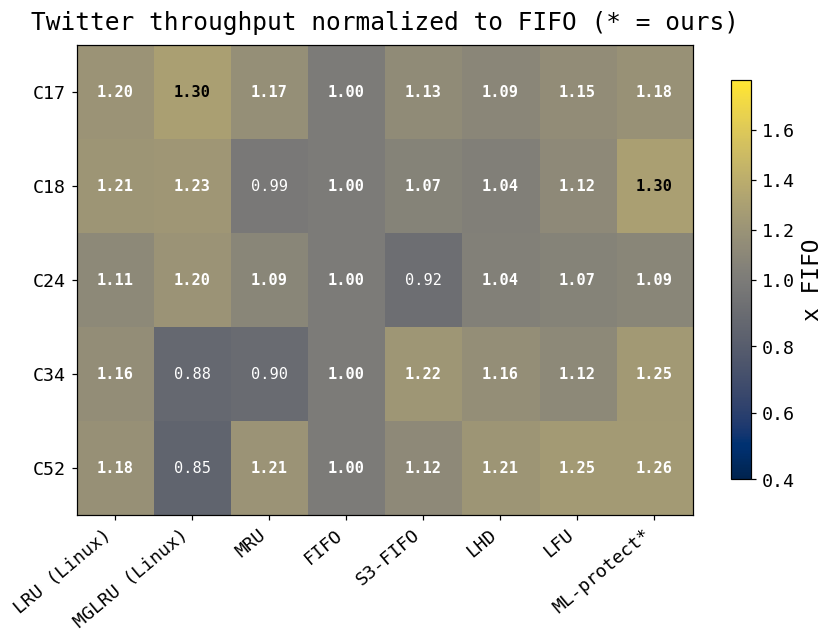

In [24]:
# Twitter throughput heatmap, normalized to FIFO
if not TWITTER_OK:
    print('No Twitter results - skipping FIFO heatmap.')
elif 'FIFO (cache_ext)' not in ttput.columns:
    print('No FIFO rows - skipping heatmap.')
else:
    HEAT_POLS = [p for p in (['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)']
                 + [f'ML-rank {f}x (ours)' for f in (10, 20, 30, 40)]) if p in ttput.columns]
    base = ttput['FIFO (cache_ext)'].reindex(TWITTER_WL)
    norm = (ttput[HEAT_POLS].reindex(TWITTER_WL).T / base).T
    with plt.rc_context({'axes.grid': False}):
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(norm.values, cmap='cividis',
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.8), aspect='auto')
        ax.set_xticks(range(len(HEAT_POLS)))
        ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                            for p in HEAT_POLS], rotation=40, ha='right')
        ax.set_yticks(range(len(TWITTER_WL)))
        ax.set_yticklabels(TWITTER_WLABELS)
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                v = norm.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
        ax.set_title('Twitter throughput normalized to FIFO (* = ours)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='x FIFO')
        fig.tight_layout()
        fig.savefig(os.path.join(FIGS, 'fig13b_twitter_norm_heatmap_vs_fifo.png'))
        plt.show()

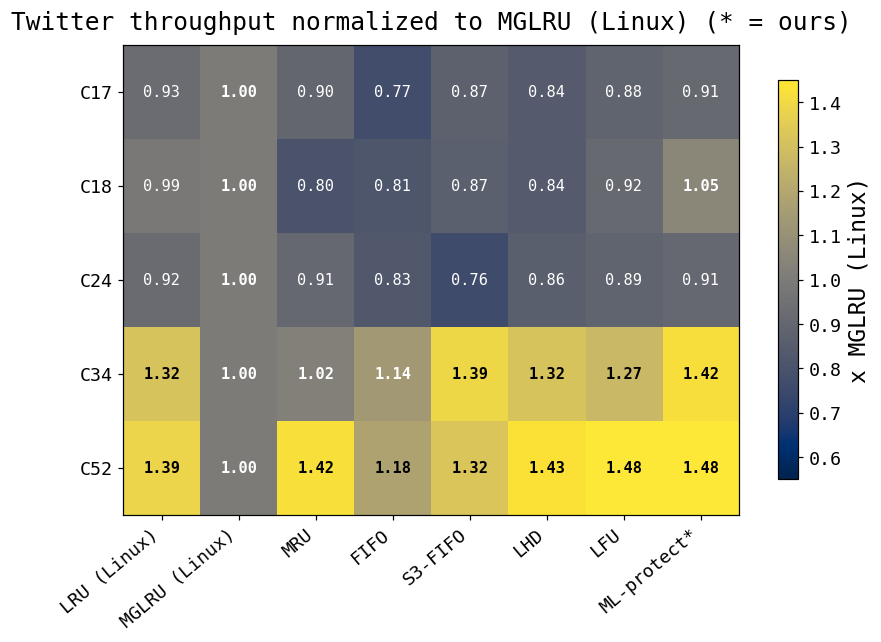

In [25]:
# Twitter throughput heatmap, normalized to Linux MGLRU
if not TWITTER_OK:
    print('No Twitter results - skipping Linux MGLRU heatmap.')
elif 'MGLRU (Linux)' not in ttput.columns:
    print('No MGLRU rows - skipping heatmap.')
else:
    HEAT_POLS = [p for p in (['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)']
                 + [f'ML-rank {f}x (ours)' for f in (10, 20, 30, 40)]) if p in ttput.columns]
    base = ttput['MGLRU (Linux)'].reindex(TWITTER_WL)
    norm = (ttput[HEAT_POLS].reindex(TWITTER_WL).T / base).T
    with plt.rc_context({'axes.grid': False}):
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(norm.values, cmap='cividis',
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.45), aspect='auto')
        ax.set_xticks(range(len(HEAT_POLS)))
        ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                            for p in HEAT_POLS], rotation=40, ha='right')
        ax.set_yticks(range(len(TWITTER_WL)))
        ax.set_yticklabels(TWITTER_WLABELS)
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                v = norm.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
        ax.set_title('Twitter throughput normalized to MGLRU (Linux) (* = ours)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='x MGLRU (Linux)')
        fig.tight_layout()
        fig.savefig(os.path.join(FIGS, 'fig13c_twitter_norm_heatmap_vs_mglru.png'))
        plt.show()

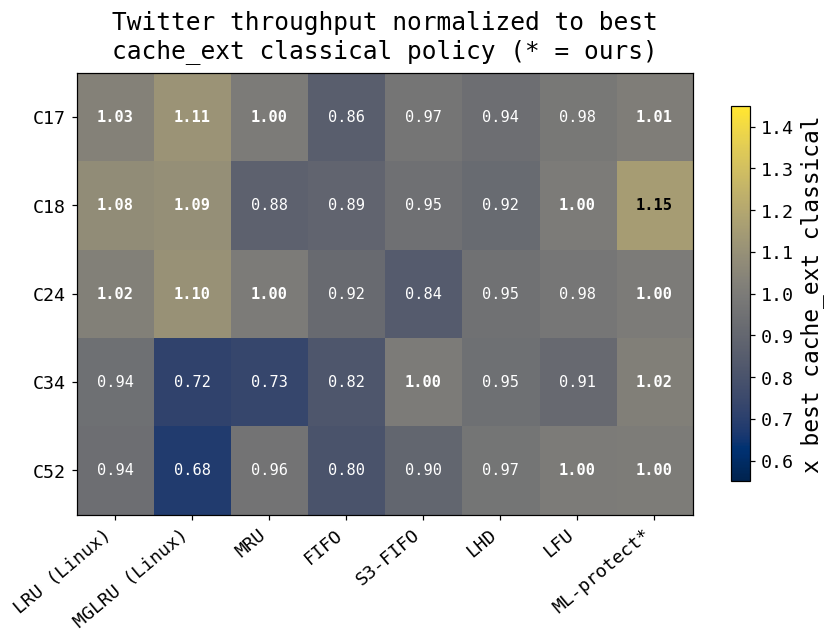

In [26]:
# Twitter throughput heatmap, normalized to best cache_ext classical (no kernel)
if not TWITTER_OK:
    print('No Twitter results - skipping best cache_ext classical (no kernel) heatmap.')
else:
    HEAT_POLS = [p for p in (['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)']
                 + [f'ML-rank {f}x (ours)' for f in (10, 20, 30, 40)]) if p in ttput.columns]
    base = ttput[[p for p in CLASSICAL if p in ttput.columns]].reindex(TWITTER_WL).max(axis=1)
    norm = (ttput[HEAT_POLS].reindex(TWITTER_WL).T / base).T
    with plt.rc_context({'axes.grid': False}):
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(norm.values, cmap='cividis',
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.45), aspect='auto')
        ax.set_xticks(range(len(HEAT_POLS)))
        ax.set_xticklabels([disp(p).replace(' (cache_ext)', '').replace(' (ours)', '*')
                            for p in HEAT_POLS], rotation=40, ha='right')
        ax.set_yticks(range(len(TWITTER_WL)))
        ax.set_yticklabels(TWITTER_WLABELS)
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                v = norm.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            color=text_on(im.cmap(im.norm(v))), fontweight='bold' if v >= 1.0 else 'normal')
        ax.set_title('Twitter throughput normalized to best\ncache_ext classical policy (* = ours)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='x best cache_ext classical')
        fig.tight_layout()
        fig.savefig(os.path.join(FIGS, 'fig13d_twitter_norm_heatmap_best_cache_ext_classical.png'))
        plt.show()

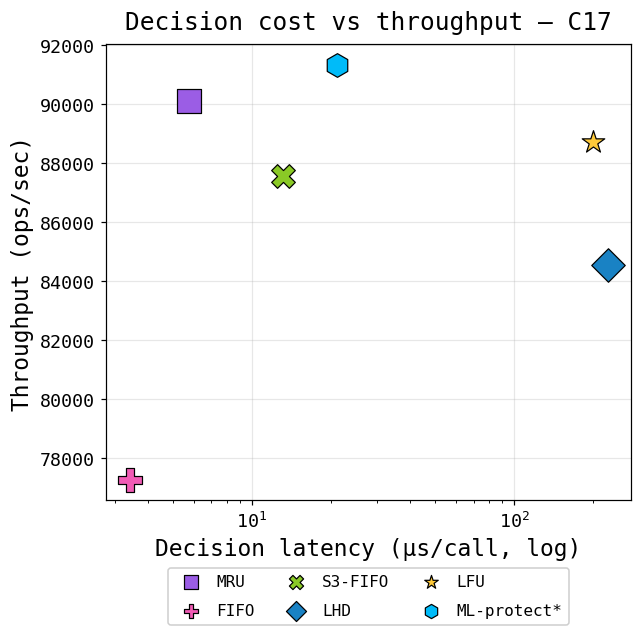

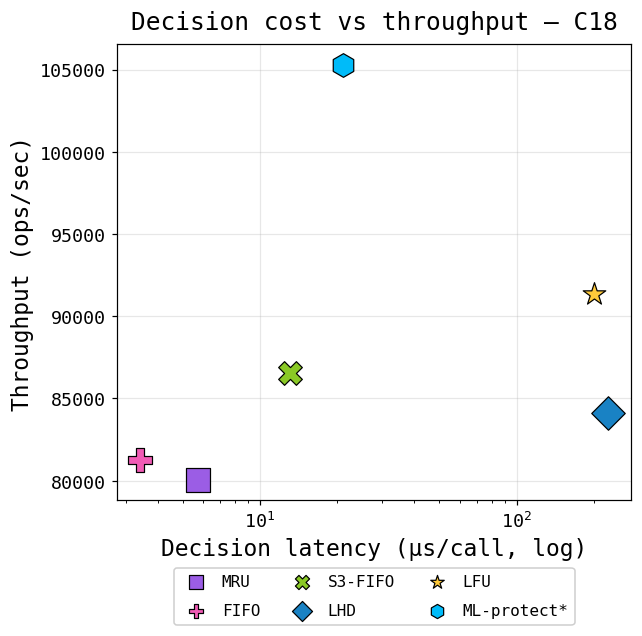

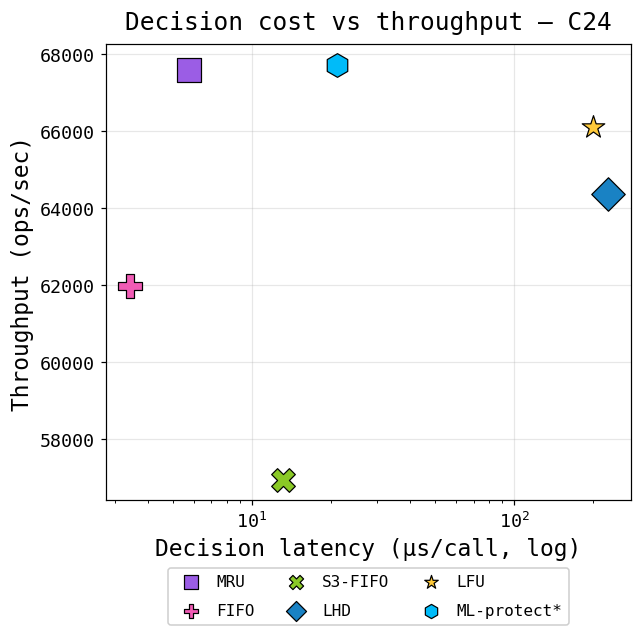

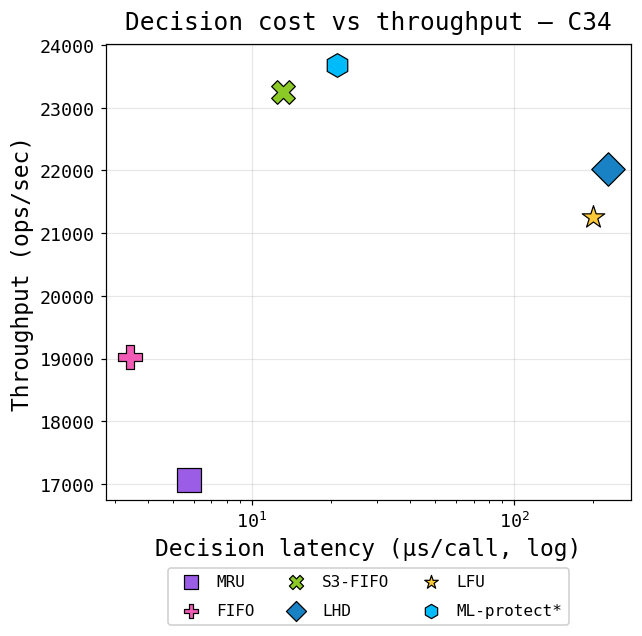

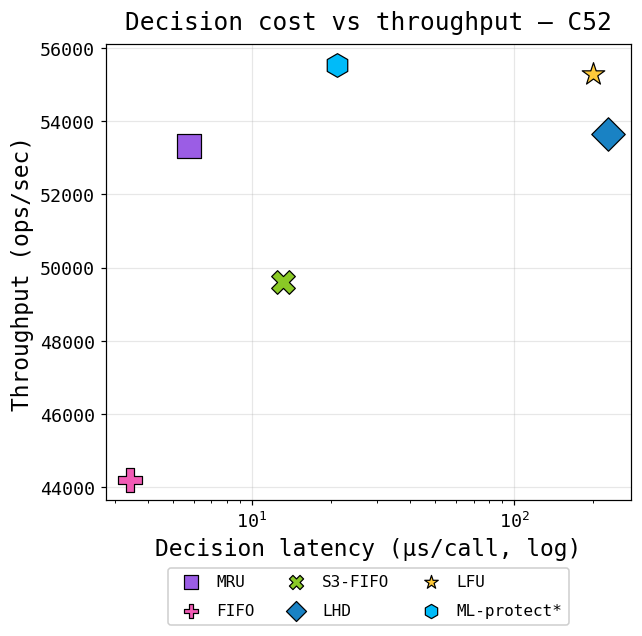

In [27]:
# Decision cost vs delivered throughput -> individual per-Twitter-cluster panels in a subdir.
# decision latency is YCSB-measured (no Twitter-native traces); a policy-intrinsic proxy.
if not TWITTER_OK:
    print('No Twitter results - skipping cost-vs-throughput figure.')
else:
    TW_PAIR = {'mru': 'MRU (cache_ext)', 'fifo': 'FIFO (cache_ext)',
               's3fifo': 'S3-FIFO (cache_ext)', 'lhd': 'LHD (cache_ext)',
               'sampling': 'LFU (cache_ext)', 'mlprotect': 'ML-protect (ours)'}
    pairs = [(t, c) for t, c in TW_PAIR.items() if t in lat_us and c in ttput.columns]
    SUBDIR = os.path.join(FIGS, 'fig14_twitter_cost_vs_throughput')
    os.makedirs(SUBDIR, exist_ok=True)
    for clab, wl in zip(TWITTER_WLABELS, TWITTER_WL):
        fig, ax = plt.subplots(figsize=(6, 6))
        for tag, col in pairs:
            y = ttput.loc[wl, col]
            if not np.isfinite(y):
                continue
            ax.scatter(np.mean(lat_us[tag]), y, s=240, color=COLORS[col],
                       marker=MARKERS.get(col, 'o'), edgecolor='black', linewidth=0.8, zorder=3,
                       label=col.replace(' (cache_ext)', '').replace(' (ours)', '*'))
        ax.set_xscale('log')
        ax.set_title('Decision cost vs throughput — ' + clab)
        ax.set_xlabel('Decision latency (µs/call, log)')
        ax.set_ylabel('Throughput (ops/sec)')
        ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.13),
                  markerscale=0.6, labelspacing=0.9, columnspacing=1.6, handletextpad=0.6)
        fig.tight_layout()
        fig.savefig(os.path.join(SUBDIR, clab + '.png'))
        plt.show()
